Dylan Ross

Analyze the mutation profiles across the AML disparities cohort for genes of interest (Eisfeld paper).

## Setup

### Imports

In [111]:
import os
import itertools

import polars as pl
from matplotlib import pyplot as plt, patches, rcParams

### Constants

In [123]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")

FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures"
)

### Load metadata from cached file

In [4]:
meta = pl.read_ipc(META_CACHE)
meta

Sample,Age,Sex,Race,Study,FLT3_ITD,IDH1+IDH2,NPM1,NRAS
str,f64,str,str,str,bool,bool,bool,bool
"""11-00261""",74.0,"""Male""","""White""","""BeatAML""",true,false,false,false
"""11-00503""",54.0,"""Female""","""White""","""BeatAML""",true,false,true,false
"""11-00475""",65.0,"""Male""","""White""","""BeatAML""",true,false,true,false
"""12-00032""",70.0,"""Male""","""White""","""BeatAML""",true,false,false,false
"""11-00376""",49.0,"""Male""","""White""","""BeatAML""",true,false,true,false
…,…,…,…,…,…,…,…,…
"""16-01109-Bridge""",33.0,"""Male""","""Black""","""pilotStudy""",false,false,false,false
"""16-01191-Bridge""",65.0,"""Female""","""White""","""pilotStudy""",false,false,false,true
"""17-00025-Bridge""",39.0,"""Female""","""White""","""pilotStudy""",true,false,true,false


## Analysis

### Summary UpSet Plot

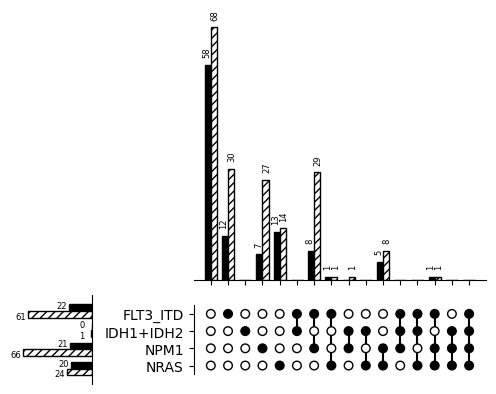

In [129]:
# --- setup ---

# figure and subpanels
fig, ((ax_nw, ax_ne), (ax_sw, ax_se)) = plt.subplots(
    nrows=2, 
    ncols=2,
    height_ratios=(3, 1),
    width_ratios=(1, 4),
    figsize=(5, 4),
)

# max font size 
rcParams["font.size"] = 8

# colors
c_white = "w"
c_black = "k"
c_border = c_black

# misc parameters
w = 0.35            # bar width
lw = 1              # line width for borders
r = 0.25            # circle radius
hatch = "////"      # hatching for white bars
split_y = False     # split the y-axis in the top bar plot
count_pad = 2       # pad the counts up from the tops of the bars by a bit

# key: mutation name
# value: y-index in upset plot
mut_to_y = {
    "FLT3_ITD": 4,
    "IDH1+IDH2": 3,
    "NPM1": 2,
    "NRAS": 1
}

# add a separate y axis for white and black groups
# black is main y axis white is secondary y axis
# only if split_y flag is set
ax_ne2 = ax_ne.twinx() if split_y else ax_ne


# --- plot the data ---


# iterate through all combinations of mutations from lowest to highest
# fill in the top bars and bottom dots
x = 0
for n in range(5):
    for true_set in itertools.combinations(mut_to_y.keys(), n):
        x += 1
        false_set = set(mut_to_y.keys()) - set(true_set)
        # black bars
        b_count = len(
            meta.filter(
                (pl.col("Race") == "Black")
            ).filter(
                pl.all_horizontal(
                    *[pl.col(c) for c in  true_set],
                    *[~pl.col(c) for c in false_set]
                )
            )
        )
        ax_ne.bar(
            [x], 
            [b_count],
            width=-w,  # align to right edge
            align="edge",
            facecolor=c_black,
            edgecolor=c_border,
            linewidth=lw,
        )
        # label each bar with the count (if count > 0)
        if b_count > 0:
            ax_ne.text(
                x - w / 1.5,
                b_count + count_pad,
                b_count,
                va="bottom",
                ha="center",
                rotation="vertical",
                fontsize=6
            )
        # white bars
        w_count = len(
            meta.filter(
                (pl.col("Race") == "White")
            ).filter(
                pl.all_horizontal(
                    *[pl.col(c) for c in  true_set],
                    *[~pl.col(c) for c in false_set]
                )
            )
        )
        ax_ne2.bar(
            [x], 
            [w_count], 
            width=w,  # align to left edge
            align="edge",
            facecolor=c_white,
            edgecolor=c_border,
            linewidth=lw,
            hatch=hatch
        )
        # label each bar with the count (for counts > 0)
        if w_count > 0:
            ax_ne2.text(
                x + w / 1.5,
                w_count + count_pad,
                w_count,
                va="bottom",
                ha="center",
                rotation="vertical",
                fontsize=6
            )
        # dots
        if len(true_set) > 1:
            ys = [mut_to_y[tm] for tm in true_set]
            ax_se.plot(
                [x, x], 
                [min(ys), max(ys)], 
                "k-", 
                lw=1.5,
                zorder=-1
            )
        for t_mut in true_set:
            ax_se.add_patch(patches.Circle(
                (x, mut_to_y[t_mut]),
                radius=r,
                facecolor="k",
                edgecolor=c_border,
                linewidth=lw
            ))
        for f_mut in false_set:
            ax_se.add_patch(patches.Circle(
            (x, mut_to_y[f_mut]),
            radius=r,
            facecolor="w",
            edgecolor=c_border,
            linewidth=lw
        ))
            
# add bars aggregating mutations across combinations
for mut, y in mut_to_y.items():
    # black bars
    b_count = len(
        meta.filter(
            (pl.col("Race") == "Black")
            & pl.col(mut)
        )
    )
    ax_sw.barh(
        [y],
        [b_count],
        height=w,  # align to bottom edge
        align="edge",
        facecolor=c_black,
        edgecolor=c_border,
        linewidth=lw,
    )
    ax_sw.text(
        b_count + count_pad * 6,
        y + w / 1.25,
        b_count,
        va="center",
        fontsize=6
    )
    # white bars
    w_count = len(
        meta.filter(
            (pl.col("Race") == "White")
            & pl.col(mut)
        )
    )
    ax_sw.barh(
        [y],
        [w_count],
        height=-w,  # align to top edge
        align="edge",
        facecolor=c_white,
        edgecolor=c_border,
        linewidth=lw,
        hatch=hatch
    )
    ax_sw.text(
        w_count + count_pad * 6,
        y - w / 1.25,
        w_count,
        va="center",
        fontsize=6
    )

# --- customization ---

# NW
ax_nw.axis("off")

# NE
ax_ne.set_xticks(range(1, x + 1))
ax_ne.set_xlim((0, x + 1))
ax_ne.set_xticklabels([])
ax_ne.set_yticks([])
for d in ["top", "right", "left"]:
    ax_ne.spines[d].set_visible(False)
if split_y:
    # only perform this additional customization if we split the y axis
    ax_ne.set_ylabel("Black")
    ax_ne2.set_ylabel("White")
    ax_ne2.set_xticklabels([])
    ax_ne2.set_xlim((0, x + 1))
    ax_ne2.set_xticks(range(1, x + 1))
    ax_ne2.set_yticks([])
    for d in ["top", "left", "right"]:
        ax_ne2.spines[d].set_visible(False)

# SW
for d in ["top", "left", "bottom"]:
    ax_sw.spines[d].set_visible(False)
ax_sw.set_yticks([])
ax_sw.set_xticks([])
ax_sw.invert_xaxis()
ax_sw.set_ylim((0.2, 4.8))

# SE
ax_se.set_xlim((0, x + 1))
ax_se.set_xticks([])
ax_se.set_ylim((0.5, 4.5))
ax_se.set_yticks(list(mut_to_y.values()))
ax_se.set_yticklabels([k for k, v in sorted(mut_to_y.items(), key=lambda t: t[1], reverse=True)])
for d in ["top", "right", "bottom"]:
    ax_se.spines[d].set_visible(False)
ax_se.set_aspect("equal")


# --- finish ---
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_DIR, "mutations_upset_race-stratified.png"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()